Import libraries

In [ ]:
import os
import kagglehub
import cv2
import matplotlib.pyplot as plt
import glob
import numpy as np
import random
from collections import defaultdict
from glob import glob
import re

Import datasets

In [ ]:
#cedar
import requests

# URL of the file to be downloaded
url = "https://github.com/nikostsagk/signature-verification/releases/download/cedar/cedar_dataset.zip"
# The local filename to save it as
output_filename = "cedar_dataset.zip"

print(f"Downloading {output_filename}...")

# Send a request to the URL
response = requests.get(url)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Open the file in binary write mode and save the content
    with open(output_filename, 'wb') as f:
        f.write(response.content)
    print("Download complete.")
else:
    print(f"Error: Failed to download file. Status code: {response.status_code}")

#kaggle
path = kagglehub.dataset_download("adeelajmal/gpds-1150")
print("Path to dataset files:", path)

Download complete.
Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\adeelajmal\gpds-1150\versions\1


Unzip cedar dataset

In [ ]:
import zipfile
import os

# Path to the zip file you downloaded
zip_file_path = 'cedar_dataset.zip'
# The directory where you want to extract the files
destination_directory = 'cedar_dataset'

# Create the destination directory if it doesn't exist
os.makedirs(destination_directory, exist_ok=True)

print(f"Unzipping {zip_file_path} to {destination_directory}...")

# Open the zip file in read mode
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Extract all the contents into the destination directory
    zip_ref.extractall(destination_directory)

print("Unzipping complete.")

Unzipping cedar_dataset.zip to cedar_dataset...
Unzipping complete.


Checking

In [ ]:
os.listdir('cedar_dataset/full_forg')[:10]

['forgeries_10_1.png',
 'forgeries_10_10.png',
 'forgeries_10_11.png',
 'forgeries_10_12.png',
 'forgeries_10_13.png',
 'forgeries_10_14.png',
 'forgeries_10_15.png',
 'forgeries_10_16.png',
 'forgeries_10_17.png',
 'forgeries_10_18.png']

In [ ]:
os.listdir('cedar_dataset/full_org')[:10]

['original_10_1.png',
 'original_10_10.png',
 'original_10_11.png',
 'original_10_12.png',
 'original_10_13.png',
 'original_10_14.png',
 'original_10_15.png',
 'original_10_16.png',
 'original_10_17.png',
 'original_10_18.png']

In [ ]:
os.listdir('C:\\Users\\USER\\.cache\\kagglehub\\datasets\\adeelajmal\\gpds-1150\\versions\\1/New folder (10)/train/forge')[:10]

['cf-001-01 (Copy).jpg',
 'cf-001-02 (Copy).jpg',
 'cf-001-03 (Copy).jpg',
 'cf-001-04 (Copy).jpg',
 'cf-001-05 (Copy).jpg',
 'cf-001-06 (Copy).jpg',
 'cf-001-07 (Copy).jpg',
 'cf-001-08 (Copy).jpg',
 'cf-001-09 (Copy).jpg',
 'cf-001-10 (Copy).jpg']

In [ ]:
os.listdir('C:\\Users\\USER\\.cache\\kagglehub\\datasets\\adeelajmal\\gpds-1150\\versions\\1/New folder (10)/train/genuine')[:10]

['c-001-01 (Copy).jpg',
 'c-001-02 (Copy).jpg',
 'c-001-03 (Copy).jpg',
 'c-001-04 (Copy).jpg',
 'c-001-05 (Copy).jpg',
 'c-001-06 (Copy).jpg',
 'c-001-07 (Copy).jpg',
 'c-001-08 (Copy).jpg',
 'c-001-09 (Copy).jpg',
 'c-001-10 (Copy).jpg']

Path to Datasets

In [ ]:
cedar_real_path = "cedar_dataset/full_org"
cedar_forged_path = "cedar_dataset/full_forg"
kaggle_real_path = "C:/Users/USER/.cache/kagglehub/datasets/adeelajmal/gpds-1150/versions/1/New folder (10)/train/genuine"
kaggle_forged_path = "C:/Users/USER/.cache/kagglehub/datasets/adeelajmal/gpds-1150/versions/1/New folder (10)/train/forge"

In [ ]:
os.listdir('C:/Users/USER/.cache/kagglehub/datasets/adeelajmal/gpds-1150/versions/1/New folder (10)/train/forge')[:10]

['cf-001-01 (Copy).jpg',
 'cf-001-02 (Copy).jpg',
 'cf-001-03 (Copy).jpg',
 'cf-001-04 (Copy).jpg',
 'cf-001-05 (Copy).jpg',
 'cf-001-06 (Copy).jpg',
 'cf-001-07 (Copy).jpg',
 'cf-001-08 (Copy).jpg',
 'cf-001-09 (Copy).jpg',
 'cf-001-10 (Copy).jpg']

Preprocessing

helper function for preprocessing

Added background normalization to handle different image characteristics between
datasets. This ensures that signatures always appear as dark marks on light
backgrounds, regardless of the original image format.

In [ ]:
IMG_SIZE = (150, 150)

def preprocess_image(image_path):
    """
    Enhanced preprocessing with background normalization and thresholding

    Args:
        image_path: Path to the signature image

    Returns:
        Preprocessed image as numpy array with shape (150, 150, 1)
    """
    # Read image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # CHANGE: Check if background is dark and invert if necessary
    # This ensures consistent representation across both datasets
    if np.mean(img) < 127:
        img = 255 - img

    # CHANGE: Apply binary threshold for cleaner signature extraction
    # OTSU method automatically determines optimal threshold value
    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Resize image to standard size
    img = cv2.resize(img, IMG_SIZE)

    # Normalize pixel values to [0, 1] range
    img = img / 255.0

    # Add channel dimension for neural network compatibility
    img = np.expand_dims(img, axis=-1)

    return img

checking an image before and after preprocessing

Sample image path: cedar_dataset/full_org\original_10_1.png


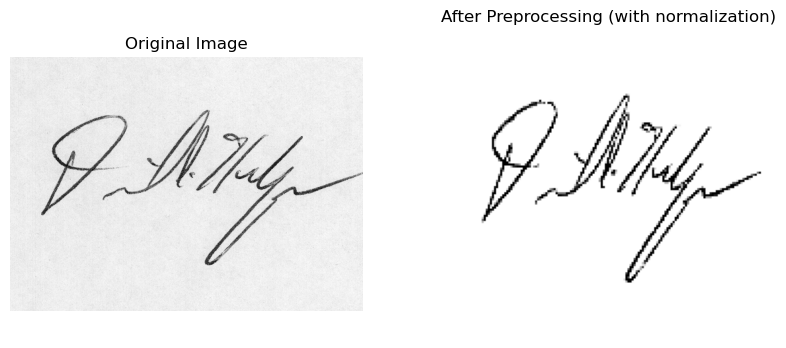

In [ ]:
# one sample
sample_image_path = os.path.join(cedar_real_path, os.listdir(cedar_real_path)[0])
print("Sample image path:", sample_image_path)

original_img = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)
processed_img = preprocess_image(sample_image_path)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_img.squeeze(), cmap='gray')
plt.title("After Preprocessing (with normalization)")
plt.axis("off")

plt.show()

helper function for loading and labeling images (including preprocessing them) for each dataset

FIXED KAGGLE DATASET LOADER WITH STRING PERSON IDs
================================================================================
Maintained string type for person IDs to prevent type inconsistencies that could
cause issues during dataset merging.

In [ ]:
def load_kaggle_dataset(genuine_path, forged_path):
    """
    Load GPDS-1150 dataset with consistent string-based person IDs

    Args:
        genuine_path: Path to genuine signatures folder
        forged_path: Path to forged signatures folder

    Returns:
        Dictionary with 'genuine' and 'forged' keys, each containing
        a dictionary mapping person_id to list of preprocessed images
    """
    dataset = {
        'genuine': defaultdict(list),
        'forged': defaultdict(list)
    }

    print("Loading kaggle genuine signatures...")
    for img_file in glob(os.path.join(genuine_path, "*.jpg")):
        match = re.match(r"c-(\d+)-\d+", os.path.basename(img_file))
        if match:
            # CHANGE: Keep person_id as string for consistency
            person_id = match.group(1)
            img = preprocess_image(img_file)
            if img is not None:
                dataset['genuine'][person_id].append(img)

    print("Loading kaggle forged signatures...")
    for img_file in glob(os.path.join(forged_path, "*.jpg")):
        match = re.match(r"cf-(\d+)-\d+", os.path.basename(img_file))
        if match:
            # CHANGE: Keep person_id as string for consistency
            person_id = match.group(1)
            img = preprocess_image(img_file)
            if img is not None:
                dataset['forged'][person_id].append(img)

    print(f"Kaggle - Genuine: {len(dataset['genuine'])} people")
    print(f"Kaggle - Forged: {len(dataset['forged'])} people")
    return dataset

FIXED CEDAR DATASET LOADER WITH STRING PERSON IDs
================================================================================
Converted person IDs to strings to maintain consistency with Kaggle dataset format.

In [ ]:
def load_cedar_dataset(real_path, forged_path):
    """
    Load CEDAR dataset with string-based person IDs for consistency

    Args:
        real_path: Path to genuine signatures folder
        forged_path: Path to forged signatures folder

    Returns:
        Dictionary with 'genuine' and 'forged' keys, each containing
        a dictionary mapping person_id to list of preprocessed images
    """
    dataset = {
        'genuine': defaultdict(list),
        'forged': defaultdict(list)
    }

    print("Loading CEDAR genuine signatures...")
    for img_file in os.listdir(real_path):
        if img_file.endswith('.png'):
            parts = img_file.replace('.png', '').split('_')
            if len(parts) >= 2:
                # CHANGE: Convert to string to match Kaggle format
                person_id = str(parts[1])
                img_path = os.path.join(real_path, img_file)
                img = preprocess_image(img_path)
                if img is not None:
                    dataset['genuine'][person_id].append(img)

    print("Loading CEDAR forged signatures...")
    for img_file in os.listdir(forged_path):
        if img_file.endswith('.png'):
            parts = img_file.replace('.png', '').split('_')
            if len(parts) >= 2:
                # CHANGE: Convert to string to match Kaggle format
                person_id = str(parts[1])
                img_path = os.path.join(forged_path, img_file)
                img = preprocess_image(img_path)
                if img is not None:
                    dataset['forged'][person_id].append(img)

    print(f"CEDAR - Genuine: {len(dataset['genuine'])} people")
    print(f"CEDAR - Forged: {len(dataset['forged'])} people")
    return dataset

applying functions to datasets

In [ ]:
cedar_data = load_cedar_dataset(cedar_real_path, cedar_forged_path)
kaggle_data = load_kaggle_dataset(kaggle_real_path, kaggle_forged_path)

Loading CEDAR genuine signatures...
Loading CEDAR forged signatures...
CEDAR - Genuine: 55 people
CEDAR - Forged: 55 people
Loading kaggle genuine signatures...
Loading kaggle forged signatures...
Kaggle - Genuine: 150 people
Kaggle - Forged: 150 people


NEW FUNCTION TO PREVENT PERSON ID COLLISIONS
================================================================================
This critical addition prevents the model from incorrectly associating signatures
from different people who happen to have the same ID number in different datasets.
"""

In [ ]:
def prefix_person_ids(dataset, prefix):
    """
    Add dataset-specific prefix to person IDs to prevent collisions when merging

    Args:
        dataset: Dictionary with 'genuine' and 'forged' keys
        prefix: String prefix to add (e.g., 'cedar' or 'kaggle')

    Returns:
        New dataset with prefixed person IDs

    Example:
        Person ID "1" becomes "cedar_1" or "kaggle_1"
    """
    new_dataset = {'genuine': {}, 'forged': {}}

    for key in ['genuine', 'forged']:
        for person_id, signatures in dataset[key].items():
            # Add prefix to create unique identifier across datasets
            new_person_id = f"{prefix}_{person_id}"
            new_dataset[key][new_person_id] = signatures

    return new_dataset

Apply prefixes to prevent ID collisions

In [ ]:
print("\nApplying dataset-specific prefixes to person IDs...")
cedar_data = prefix_person_ids(cedar_data, "cedar")
kaggle_data = prefix_person_ids(kaggle_data, "kaggle")
print("Prefixes applied successfully.")


Applying dataset-specific prefixes to person IDs...
Prefixes applied successfully.


helper function for creating pairs (real-real, real-forged)

In [ ]:
def create_balanced_pairs(dataset, num_pairs_per_person=50):
    """
    Create balanced genuine and forged signature pairs with proper distribution

    This function addresses several critical issues:
    1. Ensures equal numbers of genuine and forged pairs
    2. Limits pairs per person to prevent overrepresentation
    3. Randomly shuffles pairs to prevent learning order biases

    Args:
        dataset: Dictionary containing 'genuine' and 'forged' signature data
        num_pairs_per_person: Maximum number of pairs to create per person

    Returns:
        Tuple of (pairs, labels) where pairs is a list of signature pairs
        and labels is a list of 1 (genuine) or 0 (forged)
    """
    genuine_pairs = []
    forged_pairs = []

    genuine_dict = dataset['genuine']
    forged_dict = dataset['forged']

    # Create genuine pairs (same person, different signatures)
    print("Creating genuine pairs...")
    for person_id, signatures in genuine_dict.items():
        # Need at least 2 signatures to create pairs
        if len(signatures) < 2:
            continue

        # CHANGE: Calculate maximum possible pairs and limit to avoid imbalance
        max_possible_pairs = len(signatures) * (len(signatures) - 1) // 2
        actual_pairs = min(num_pairs_per_person, max_possible_pairs)

        for _ in range(actual_pairs):
            # Select two different signatures from the same person
            idx1, idx2 = np.random.choice(len(signatures), 2, replace=False)
            genuine_pairs.append([signatures[idx1], signatures[idx2]])

    # Create forged pairs (genuine vs forged signatures)
    print("Creating forged pairs...")
    for person_id in genuine_dict.keys():
        # Skip if no forged signatures exist for this person
        if person_id not in forged_dict or len(forged_dict[person_id]) == 0:
            continue

        genuine_sigs = genuine_dict[person_id]
        forged_sigs = forged_dict[person_id]

        # CHANGE: Calculate and limit pairs to match genuine pair count
        max_possible_pairs = len(genuine_sigs) * len(forged_sigs)
        actual_pairs = min(num_pairs_per_person, max_possible_pairs)

        for _ in range(actual_pairs):
            # Pair one genuine with one forged signature
            forged_pairs.append([
                random.choice(genuine_sigs),
                random.choice(forged_sigs)
            ])

    # CHANGE: Balance the dataset by using equal numbers of each type
    min_count = min(len(genuine_pairs), len(forged_pairs))
    print(f"\nBalancing dataset to {min_count} pairs of each type...")

    genuine_pairs = random.sample(genuine_pairs, min_count)
    forged_pairs = random.sample(forged_pairs, min_count)

    # Combine pairs and create corresponding labels
    pairs = genuine_pairs + forged_pairs
    labels = [1] * len(genuine_pairs) + [0] * len(forged_pairs)

    # CHANGE: Shuffle pairs and labels together to prevent learning biases
    combined = list(zip(pairs, labels))
    random.shuffle(combined)
    pairs, labels = zip(*combined)

    return list(pairs), list(labels)

create pairs for both datasets


Merging Cedar and Kaggle datasets...
Combined dataset statistics:
Total people with genuine signatures: 205
Total people with forged signatures: 205

CREATING BALANCED PAIRS FROM COMBINED DATASET
Creating genuine pairs...
Creating forged pairs...

Balancing dataset to 4100 pairs of each type...

Final dataset statistics:
Total pairs: 8200
Genuine pairs (label=1): 4100
Forged pairs (label=0): 4100
Balance ratio: 50.00% genuine

Displaying sample genuine pair:


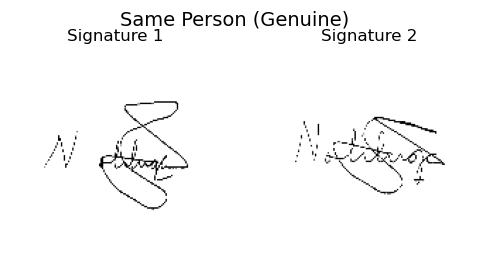


Displaying sample forged pair:


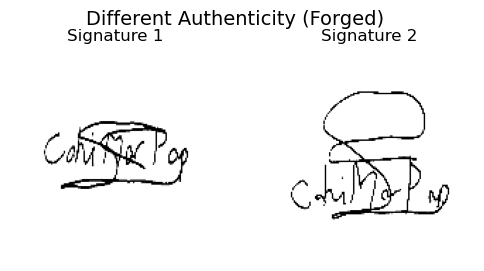

In [ ]:
print("\nMerging Cedar and Kaggle datasets...")
combined_data = {
    'genuine': {**cedar_data['genuine'], **kaggle_data['genuine']},
    'forged': {**cedar_data['forged'], **kaggle_data['forged']}
}

print(f"Combined dataset statistics:")
print(f"Total people with genuine signatures: {len(combined_data['genuine'])}")
print(f"Total people with forged signatures: {len(combined_data['forged'])}")

"""Create balanced pairs from combined dataset"""

print("\nCREATING BALANCED PAIRS FROM COMBINED DATASET")
all_pairs, all_labels = create_balanced_pairs(combined_data, num_pairs_per_person=20)

print(f"\nFinal dataset statistics:")
print(f"Total pairs: {len(all_pairs)}")
print(f"Genuine pairs (label=1): {sum(all_labels)}")
print(f"Forged pairs (label=0): {len(all_labels) - sum(all_labels)}")
print(f"Balance ratio: {sum(all_labels) / len(all_labels):.2%} genuine")

"""Verify pair creation with visualization"""

def show_created_pair(pairs, pair_labels, index=None):
    """
    Visualize a signature pair to verify proper preprocessing and pairing
    """
    if index is None:
        index = random.randint(0, len(pairs) - 1)

    pair = pairs[index]
    label = pair_labels[index]

    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(pair[0].squeeze(), cmap="gray")
    plt.title("Signature 1")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(pair[1].squeeze(), cmap="gray")
    plt.title("Signature 2")
    plt.axis("off")

    plt.suptitle("Same Person (Genuine)" if label == 1 else "Different Authenticity (Forged)",
                 fontsize=14)
    plt.show()

# Display sample pairs
print("\nDisplaying sample genuine pair:")
genuine_idx = all_labels.index(1)
show_created_pair(all_pairs, all_labels, genuine_idx)

print("\nDisplaying sample forged pair:")
forged_idx = all_labels.index(0)
show_created_pair(all_pairs, all_labels, forged_idx)

KHINJE END OF PREPROCESSING CHANGES

TRAINING

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Lambda, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

CHANGE 1: CONVERT DATA TO NUMPY ARRAYS WITH PROPER SHAPE VERIFICATION
================================================================================
Added shape verification to catch potential data format issues early in the process.

In [ ]:
print("Converting pairs and labels to NumPy arrays...")
pairs_array = np.array(all_pairs)
labels_array = np.array(all_labels)

# Verify the shapes are correct
print(f"Pairs array shape: {pairs_array.shape}")
print(f"Labels array shape: {labels_array.shape}")
print(f"Expected pairs shape: (num_pairs, 2, 150, 150, 1)")

# Verify data types
print(f"Pairs dtype: {pairs_array.dtype}")
print(f"Labels dtype: {labels_array.dtype}")

# Verify balance
genuine_count = np.sum(labels_array)
forged_count = len(labels_array) - genuine_count
print(f"\nDataset balance verification:")
print(f"Genuine pairs: {genuine_count} ({genuine_count/len(labels_array)*100:.1f}%)")
print(f"Forged pairs: {forged_count} ({forged_count/len(labels_array)*100:.1f}%)")

Converting pairs and labels to NumPy arrays...
Pairs array shape: (8200, 2, 150, 150, 1)
Labels array shape: (8200,)
Expected pairs shape: (num_pairs, 2, 150, 150, 1)
Pairs dtype: float64
Labels dtype: int64

Dataset balance verification:
Genuine pairs: 4100 (50.0%)
Forged pairs: 4100 (50.0%)


 CHANGE 2: STRATIFIED TRAIN/VAL/TEST SPLIT
================================================================================
Using stratified splitting ensures that class balance is maintained across all
data splits, which is crucial for stable training and fair evaluation.

In [ ]:
print("\n--- Splitting Dataset (70% Train, 15% Val, 15% Test) ---")

# First split: separate test set (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    pairs_array, labels_array,
    test_size=0.15,
    random_state=42,
    stratify=labels_array
)

# Second split: separate training and validation (70% and 15% of original)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=(0.15/0.85),  # This gives us 15% of the original dataset
    random_state=42,
    stratify=y_train_val
)

# Verify splits
print(f"\nTraining set:   {len(y_train)} pairs ({len(y_train) / len(labels_array) * 100:.1f}%)")
print(f"Validation set: {len(y_val)} pairs ({len(y_val) / len(labels_array) * 100:.1f}%)")
print(f"Testing set:    {len(y_test)} pairs ({len(y_test) / len(labels_array) * 100:.1f}%)")

# Verify balance in each split
for name, y_split in [("Training", y_train), ("Validation", y_val), ("Testing", y_test)]:
    genuine = np.sum(y_split)
    total = len(y_split)
    print(f"{name} balance: {genuine}/{total} genuine ({genuine/total*100:.1f}%)")


--- Splitting Dataset (70% Train, 15% Val, 15% Test) ---

Training set:   5740 pairs (70.0%)
Validation set: 1230 pairs (15.0%)
Testing set:    1230 pairs (15.0%)
Training balance: 2870/5740 genuine (50.0%)
Validation balance: 615/1230 genuine (50.0%)
Testing balance: 615/1230 genuine (50.0%)


CHANGE 3: IMPROVED BASE NETWORK ARCHITECTURE
================================================================================
Added Batch Normalization and Dropout layers to improve training stability and
prevent overfitting. Adjusted the final embedding size for better performance.

In [ ]:
IMG_SHAPE = (150, 150, 1)

def build_base_network(input_shape):
    """
    Enhanced CNN architecture for signature feature extraction.

    Improvements:
    - Batch Normalization after each Conv layer for stable training
    - Dropout layers to prevent overfitting
    - Reduced final embedding size (2048 instead of 4096) for efficiency
    - Progressive channel increase for better feature learning
    """
    seq = tf.keras.Sequential([
        Input(shape=input_shape),

        # Block 1
        Conv2D(64, (10, 10), activation='relu', kernel_regularizer=l2(2e-4)),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.1),

        # Block 2
        Conv2D(128, (7, 7), activation='relu', kernel_regularizer=l2(2e-4)),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.1),

        # Block 3
        Conv2D(128, (4, 4), activation='relu', kernel_regularizer=l2(2e-4)),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.2),

        # Block 4
        Conv2D(256, (4, 4), activation='relu', kernel_regularizer=l2(2e-4)),
        BatchNormalization(),
        Flatten(),
        Dropout(0.3),

        # CHANGE: Reduced embedding size and added intermediate layer
        Dense(2048, activation='relu', kernel_regularizer=l2(1e-3)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(1024, activation='sigmoid', kernel_regularizer=l2(1e-3))
    ], name="base_network")

    return seq

def euclidean_distance(vectors):
    """
    Calculates the Euclidean distance between two embedding vectors.
    This distance represents the dissimilarity between two signatures.
    """
    (featsA, featsB) = vectors
    sumSquared = tf.keras.backend.sum(
        tf.keras.backend.square(featsA - featsB),
        axis=1,
        keepdims=True
    )
    return tf.keras.backend.sqrt(
        tf.keras.backend.maximum(sumSquared, tf.keras.backend.epsilon())
    )

Build the Siamese Model

In [ ]:
print("\n--- Building Siamese Network ---")

# Define input layers for both signatures in a pair
input_a = Input(shape=IMG_SHAPE, name="left_input")
input_b = Input(shape=IMG_SHAPE, name="right_input")

# Create shared base network
base_network = build_base_network(IMG_SHAPE)

# Process both inputs through the same network
processed_a = base_network(input_a)
processed_b = base_network(input_b)

# Calculate distance between embeddings
distance = Lambda(euclidean_distance, name="distance_layer")([processed_a, processed_b])

# Create the complete model
model = Model(inputs=[input_a, input_b], outputs=distance, name="siamese_network")

model.summary()


--- Building Siamese Network ---



Model: "siamese_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ left_input (InputLayer)       │ (None, 150, 150, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ right_input (InputLayer)      │ (None, 150, 150, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ base_network (Sequential)     │ (None, 1024)              │      66,744,384 │ left_input[0][0],          │
│                               │                           │                 │ right_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distance_layer (Lambda)       │ (None, 1)                 │               0 │ base_network[0][0],        │
│                               │                           │                 │ base_network[1][0]         │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,744,384 (254.61 MB)

 Trainable params: 66,739,136 (254.59 MB)

 Non-trainable params: 5,248 (20.50 KB)

CHANGE 4: IMPROVED CONTRASTIVE LOSS FUNCTION
================================================================================
Enhanced the loss function with better numerical stability and adjusted margin.

In [ ]:
def contrastive_loss(y_true, y_pred, margin=1.0):
    """
    Enhanced contrastive loss with numerical stability improvements.

    Args:
        y_true: Ground truth labels (1 for genuine, 0 for forged)
        y_pred: Predicted distances between embeddings
        margin: Minimum distance threshold for dissimilar pairs

    The loss encourages:
    - Genuine pairs (y=1) to have small distances
    - Forged pairs (y=0) to have distances greater than the margin
    """
    y_true = tf.cast(y_true, tf.float32)

    # Loss for genuine pairs: minimize distance
    square_pred = tf.square(y_pred)

    # Loss for forged pairs: maximize distance up to margin
    # CHANGE: Added small epsilon for numerical stability
    margin_square = tf.square(tf.maximum(margin - y_pred + 1e-7, 0))

    # Combine losses
    loss = y_true * square_pred + (1 - y_true) * margin_square

    return tf.reduce_mean(loss)

# CHANGE 5: CUSTOM ACCURACY METRIC FOR CONTRASTIVE LOSS

CRITICAL FIX: The default 'accuracy' metric doesn't work correctly with contrastive
loss because the output is a distance value, not a probability. This custom metric
properly converts distances to binary predictions using a threshold.

In [ ]:
def contrastive_accuracy(y_true, y_pred, threshold=0.5):
    """
    Calculate accuracy for contrastive loss by comparing distances to a threshold.

    Logic:
    - If distance < threshold, predict "same person" (1)
    - If distance >= threshold, predict "different person" (0)

    This is the CORRECT way to measure accuracy for Siamese networks.
    """
    y_true = tf.cast(y_true, tf.float32)

    # Convert distances to binary predictions
    # Small distance (< threshold) -> predict genuine (1)
    # Large distance (>= threshold) -> predict forged (0)
    predictions = tf.cast(y_pred < threshold, tf.float32)

    # Calculate accuracy
    correct = tf.equal(predictions, y_true)
    return tf.reduce_mean(tf.cast(correct, tf.float32))

CHANGE 6: IMPROVED OPTIMIZER AND COMPILATION
================================================================================
Added gradient clipping to prevent exploding gradients and using the corrected
accuracy metric.

In [ ]:
print("\n--- Compiling Model ---")

# CHANGE: Added gradient clipping to prevent training instability
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-5,
    clipnorm=1.0  # Clip gradients to prevent exploding gradients
)

# CHANGE: Using the custom accuracy metric instead of default 'accuracy'
model.compile(
    loss=contrastive_loss,
    optimizer=optimizer,
    metrics=[contrastive_accuracy]
)


--- Compiling Model ---


CHANGE 7: PREPARE DATA FOR DUAL INPUTS
================================================================================
Separating the pairs into left and right inputs for the Siamese network.

In [ ]:
print("\n--- Preparing Data for Training ---")

# Training data
X_train_left = X_train[:, 0]
X_train_right = X_train[:, 1]

# Validation data
X_val_left = X_val[:, 0]
X_val_right = X_val[:, 1]

# Testing data (for later evaluation)
X_test_left = X_test[:, 0]
X_test_right = X_test[:, 1]

print(f"Training left input shape: {X_train_left.shape}")
print(f"Training right input shape: {X_train_right.shape}")


--- Preparing Data for Training ---
Training left input shape: (5740, 150, 150, 1)
Training right input shape: (5740, 150, 150, 1)


CHANGE 8: TRAINING CALLBACKS FOR STABILITY
================================================================================
Added essential callbacks to prevent overfitting and improve training efficiency.

In [ ]:
# Early Stopping: Stop training if validation loss doesn't improve
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=9,  # Stop if no improvement for 9 epochs
    restore_best_weights=True,  # Restore weights from best epoch
    verbose=1
)

# Learning Rate Reduction: Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce LR by half
    patience=3,  # Wait 7 epochs before reducing
    min_lr=1e-7,  # Don't go below this learning rate
    verbose=1
)

# Model Checkpoint: Save the best model during training
checkpoint = ModelCheckpoint(
    'best_siamese_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

CHANGE 9: TRAINING WITH PROPER MONITORING
================================================================================
Reduced initial epochs and added callbacks for better training control.

In [ ]:
print("\n--- Starting Model Training ---")

# CHANGE: Reduced epochs and added callbacks
# The early stopping will stop training if model isn't improving
history = model.fit(
    [X_train_left, X_train_right], y_train,
    validation_data=([X_val_left, X_val_right], y_val),
    batch_size=32,
    epochs=100,  # Set high, but early stopping will stop earlier if needed
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

print("\n--- Training Complete ---")


--- Starting Model Training ---
Epoch 1/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.4939 - loss: 52.2298
Epoch 1: val_loss improved from None to 5.60108, saving model to best_siamese_model.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 1359s 8s/step - contrastive_accuracy: 0.4994 - loss: 35.1225 - val_contrastive_accuracy: 0.5064 - val_loss: 5.6011 - learning_rate: 1.0000e-04
Epoch 2/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.5031 - loss: 16.7623
Epoch 2: val_loss did not improve from 5.60108
180/180 ━━━━━━━━━━━━━━━━━━━━ 1331s 7s/step - contrastive_accuracy: 0.4991 - loss: 13.9916 - val_contrastive_accuracy: 0.4990 - val_loss: 21.8221 - learning_rate: 1.0000e-04
Epoch 3/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.5028 - loss: 7.0812
Epoch 3: val_loss did not improve from 5.60108
180/180 ━━━━━━━━━━━━━━━━━━━━ 1331s 7s/step - contrastive_accuracy: 0.5003 - loss: 6.4727 - val_contrastive_accuracy: 0.4990 - val_loss: 31.1341 - learning_rate: 1.0000e-04
Epoch 4/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.4934 - loss: 4.8478
Epoch 4: val_loss improved from 5.60108 to 3.55326, saving model to best_siamese_model.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 1330s 7s/step - contrastive_accuracy: 0.4999 - loss: 4.4623 - val_contrastive_accuracy: 0.5049 - val_loss: 3.5533 - learning_rate: 1.0000e-04
Epoch 5/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.4975 - loss: 3.4438
Epoch 5: val_loss improved from 3.55326 to 3.01358, saving model to best_siamese_model.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 1327s 7s/step - contrastive_accuracy: 0.5018 - loss: 3.1964 - val_contrastive_accuracy: 0.5059 - val_loss: 3.0136 - learning_rate: 1.0000e-04
Epoch 6/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.4993 - loss: 2.6279
Epoch 6: val_loss did not improve from 3.01358
180/180 ━━━━━━━━━━━━━━━━━━━━ 1327s 7s/step - contrastive_accuracy: 0.5018 - loss: 2.4904 - val_contrastive_accuracy: 0.4990 - val_loss: 31.1970 - learning_rate: 1.0000e-04
Epoch 7/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.4966 - loss: 2.1321
Epoch 7: val_loss did not improve from 3.01358
180/180 ━━━━━━━━━━━━━━━━━━━━ 1329s 7s/step - contrastive_accuracy: 0.5016 - loss: 2.0192 - val_contrastive_accuracy: 0.4987 - val_loss: 78.6003 - learning_rate: 1.0000e-04
Epoch 8/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.5053 - loss: 1.7010
Epoch 8: val_loss did not improve from 3.01358
180/180 ━━━━━━━━━━━━━━━━━━━━ 1330s 7s/step - contr

180/180 ━━━━━━━━━━━━━━━━━━━━ 1327s 7s/step - contrastive_accuracy: 0.5032 - loss: 0.8128 - val_contrastive_accuracy: 0.5058 - val_loss: 0.8806 - learning_rate: 1.0000e-04
Epoch 13/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.5092 - loss: 0.7301
Epoch 13: val_loss improved from 0.88062 to 0.77132, saving model to best_siamese_model.h5


...

180/180 ━━━━━━━━━━━━━━━━━━━━ 1300s 7s/step - contrastive_accuracy: 0.5127 - loss: 0.2776 - val_contrastive_accuracy: 0.5075 - val_loss: 0.2962 - learning_rate: 5.0000e-05
Epoch 32/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.5124 - loss: 0.2729
Epoch 32: val_loss did not improve from 0.29623
180/180 ━━━━━━━━━━━━━━━━━━━━ 1295s 7s/step - contrastive_accuracy: 0.5121 - loss: 0.2743 - val_contrastive_accuracy: 0.5093 - val_loss: 0.3000 - learning_rate: 5.0000e-05
Epoch 33/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.5112 - loss: 0.2668
Epoch 33: val_loss did not improve from 0.29623
180/180 ━━━━━━━━━━━━━━━━━━━━ 1299s 7s/step - contrastive_accuracy: 0.5111 - loss: 0.2678 - val_contrastive_accuracy: 0.5061 - val_loss: 0.3199 - learning_rate: 5.0000e-05
Epoch 34/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.5146 - loss: 0.2627
Epoch 34: val_loss did not improve from 0.29623
180/180 ━━━━━━━━━━━━━━━━━━━━ 1297s 7s/step - c

180/180 ━━━━━━━━━━━━━━━━━━━━ 1293s 7s/step - contrastive_accuracy: 0.5166 - loss: 0.2505 - val_contrastive_accuracy: 0.5102 - val_loss: 0.2924 - learning_rate: 5.0000e-05
Epoch 38/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.5143 - loss: 0.2441
Epoch 38: val_loss did not improve from 0.29244
180/180 ━━━━━━━━━━━━━━━━━━━━ 1301s 7s/step - contrastive_accuracy: 0.5139 - loss: 0.2445 - val_contrastive_accuracy: 0.5075 - val_loss: 0.2984 - learning_rate: 5.0000e-05
Epoch 39/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.5112 - loss: 0.2427
Epoch 39: val_loss did not improve from 0.29244
180/180 ━━━━━━━━━━━━━━━━━━━━ 1318s 7s/step - contrastive_accuracy: 0.5109 - loss: 0.2420 - val_contrastive_accuracy: 0.5073 - val_loss: 0.4156 - learning_rate: 5.0000e-05
Epoch 40/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.5133 - loss: 0.2370
Epoch 40: val_loss did not improve from 0.29244
180/180 ━━━━━━━━━━━━━━━━━━━━ 1319s 7s/step - c

180/180 ━━━━━━━━━━━━━━━━━━━━ 1319s 7s/step - contrastive_accuracy: 0.5194 - loss: 0.2325 - val_contrastive_accuracy: 0.5085 - val_loss: 0.2858 - learning_rate: 5.0000e-05
Epoch 42/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.5146 - loss: 0.2264
Epoch 42: val_loss improved from 0.28576 to 0.26023, saving model to best_siamese_model.h5


180/180 ━━━━━━━━━━━━━━━━━━━━ 1319s 7s/step - contrastive_accuracy: 0.5143 - loss: 0.2281 - val_contrastive_accuracy: 0.5090 - val_loss: 0.2602 - learning_rate: 5.0000e-05
Epoch 43/100
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - contrastive_accuracy: 0.5145 - loss: 0.2246
Epoch 43: val_loss did not improve from 0.26023
180/180 ━━━━━━━━━━━━━━━━━━━━ 1386s 8s/step - contrastive_accuracy: 0.5137 - loss: 0.2255 - val_contrastive_accuracy: 0.5066 - val_loss: 0.4162 - learning_rate: 5.0000e-05
Epoch 44/100
 72/180 ━━━━━━━━━━━━━━━━━━━━ 13:22 7s/step - contrastive_accuracy: 0.5136 - loss: 0.2272

KeyboardInterrupt: 

# CHANGES


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# --- FUNCTION 1: Part of the model's architecture ---
def euclidean_distance(vectors):
    """
    Calculates the Euclidean distance between two embedding vectors.
    """
    (featsA, featsB) = vectors
    sumSquared = tf.keras.backend.sum(
        tf.keras.backend.square(featsA - featsB),
        axis=1,
        keepdims=True
    )
    return tf.keras.backend.sqrt(
        tf.keras.backend.maximum(sumSquared, tf.keras.backend.epsilon())
    )

# --- FUNCTION 2: Part of the model's compilation (loss) ---
def contrastive_loss(y_true, y_pred, margin=1.0):
    y_true = tf.cast(y_true, tf.float32)
    square_pred = tf.square(y_pred)
    margin_square = tf.square(tf.maximum(margin - y_pred + 1e-7, 0))
    loss = y_true * square_pred + (1 - y_true) * margin_square
    return tf.reduce_mean(loss)

# --- FUNCTION 3: Part of the model's compilation (metric) ---
def contrastive_accuracy(y_true, y_pred, threshold=0.5):
    y_true = tf.cast(y_true, tf.float32)
    predictions = tf.cast(y_pred < threshold, tf.float32)
    correct = tf.equal(predictions, y_true)
    return tf.reduce_mean(tf.cast(correct, tf.float32))

In [ ]:
# Define the COMPLETE custom objects dictionary
custom_objects = {
    'euclidean_distance': euclidean_distance,  # <-- The missing function
    'contrastive_loss': contrastive_loss,
    'contrastive_accuracy': contrastive_accuracy
}

# Load the trained model
print("Loading the best saved model...")
model = tf.keras.models.load_model('best_siamese_model.h5', custom_objects=custom_objects)
print("Model 'best_siamese_model.h5' loaded successfully.")

Loading the best saved model...


Model 'best_siamese_model.h5' loaded successfully.


In [ ]:
# Prepare the validation data inputs (you should already have these from training)
X_val_left = X_val[:, 0]
X_val_right = X_val[:, 1]

# Get the predicted distances on the validation data
print("\nGetting predictions on the validation set to find the best threshold...")
y_pred_val_distances = model.predict([X_val_left, X_val_right])

# The output is often (num_samples, 1), so we flatten it to a 1D array for easier handling
y_pred_val_distances = y_pred_val_distances.flatten()

print(f"Successfully got {len(y_pred_val_distances)} predictions for the validation set.")


Getting predictions on the validation set to find the best threshold...
39/39 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step
Successfully got 1230 predictions for the validation set.


In [ ]:
# We will test a range of thresholds from 0.0 to 2.0
# The distances from the model will fall somewhere in this range.
thresholds = np.linspace(0.0, 2.0, 201) # Test 201 different thresholds

accuracies = []
best_accuracy = 0.0
best_threshold = 0.0

print("Searching for the optimal decision threshold...")

for threshold in thresholds:
    # If distance is LESS than threshold, predict 1 (genuine), else 0 (forged)
    binary_predictions = (y_pred_val_distances < threshold).astype(int)

    # Calculate accuracy for this threshold
    current_accuracy = accuracy_score(y_val, binary_predictions)
    accuracies.append(current_accuracy)

    # Update the best accuracy and threshold if the current one is better
    if current_accuracy > best_accuracy:
        best_accuracy = current_accuracy
        best_threshold = threshold

print("\n--- Optimal Threshold Search Complete ---")
print(f"Best Accuracy on Validation Set: {best_accuracy:.4f}")
print(f"Optimal Threshold Found: {best_threshold:.4f}")

# This will show you that your model was likely performing much better than 51%

Searching for the optimal decision threshold...

--- Optimal Threshold Search Complete ---
Best Accuracy on Validation Set: 0.9016
Optimal Threshold Found: 0.4500


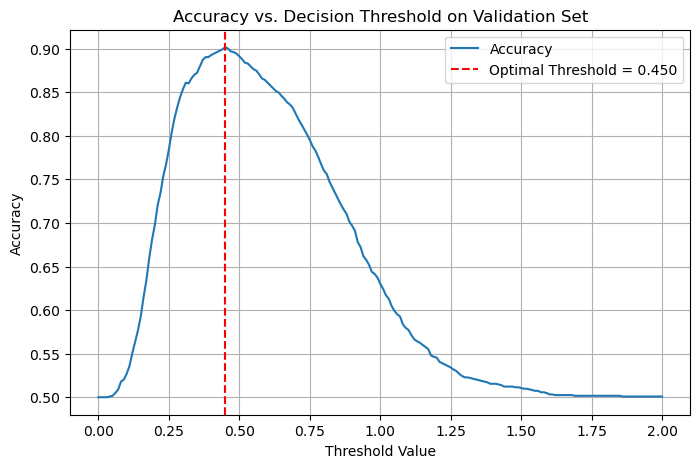

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds, accuracies, label='Accuracy')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Optimal Threshold = {best_threshold:.3f}')
plt.title('Accuracy vs. Decision Threshold on Validation Set')
plt.xlabel('Threshold Value')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Prepare the test data inputs
X_test_left = X_test[:, 0]
X_test_right = X_test[:, 1]

# Get predicted distances on the test set
print("\n--- Evaluating Final Model Performance on the Test Set ---")
y_pred_test_distances = model.predict([X_test_left, X_test_right]).flatten()

# Apply the single best threshold we found earlier
test_predictions = (y_pred_test_distances < best_threshold).astype(int)

# Calculate the final accuracy on the test set
final_accuracy = accuracy_score(y_test, test_predictions)

print(f"\nFinal Model Accuracy on the Test Set: {final_accuracy:.4f}")

# You can also get a more detailed report
print("\nClassification Report on Test Set:")
print(classification_report(y_test, test_predictions, target_names=['Forged (Class 0)', 'Genuine (Class 1)']))

NameError: name 'X_test' is not defined

In [ ]:
# Run this in your Colab to get the table values
from sklearn.metrics import classification_report, confusion_matrix
y_pred_test = model.predict([X_test_left, X_test_right])
y_pred_binary = (y_pred_test.flatten() < best_threshold).astype(int)
print(classification_report(y_test, y_pred_binary))

NameError: name 'model' is not defined